## L1實驗

In [70]:
import numpy as np
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error

In [71]:
# 生成示例數據，添加一些不相關的特徵和增加噪音
np.random.seed(42)
X, y = make_regression(n_samples=100, n_features=10, noise=10, random_state=42)
# 添加20個不相關的特徵
X = np.hstack([X, np.random.randn(100, 20)])

# 分割數據為訓練集和測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 不使用L1正則化的線性回歸模型
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Linear Regression Mean Squared Error: {mse}')

# 使用L1正則化的Lasso模型
lasso = Lasso(alpha=0.3)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
print(f'Lasso Regression Mean Squared Error: {mse_lasso}')

Linear Regression Mean Squared Error: 176.42544323621857
Lasso Regression Mean Squared Error: 159.06667378029192


In [72]:
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error


In [73]:
# 生成示例數據，添加共線性特徵
np.random.seed(42)

In [74]:
X,y = make_regression(n_samples=100, n_features=10, noise=0.1,random_state=42)
#scale 標準差
X[:,1] = X[:,0] + np.random.normal(scale=0.01, size=100)  # 添加共線性特徵
X[:,2] = X[:,0] - np.random.normal(scale=0.01, size=100)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [75]:
mse = mean_squared_error(y_test,y_pred)
print(mse)

4138.155390347969


In [76]:
ridge = Ridge(alpha=0.8)
ridge.fit(X_train,y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test,y_pred_ridge)
print(mse_ridge)

3989.1620745662985


### 網格搜索（Grid Search）

我們可以通過網格搜索來搜尋各種超參數組合。儘管許多線性模型非常簡單，甚至自帶專門的搜索版本來幫助你找到最佳參數組合，但這種網格搜索方法可以應用於 *任何* Scikit-learn 的模型。

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
df = pd.read_csv("./Advertising.csv")

In [79]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [80]:
## CREATE X and y
X = df.drop('sales',axis=1)
y = df['sales']

# TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)


# SCALE DATA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [81]:
from sklearn.linear_model import ElasticNet
base_elastic_model =  ElasticNet()

In [82]:
param_grid = {"alpha":[0.1,1,5,10,50,100],
              "l1_ratio":[.1,.5,.7,.9,.95,.1]}


In [83]:
from sklearn.model_selection import GridSearchCV

In [84]:
gird_model = GridSearchCV(estimator=base_elastic_model,
                          param_grid=param_grid,
                          scoring="neg_mean_squared_error",
                          cv=5,
                          verbose=2)
#verbose=2 意味著將顯示較為詳細的日誌訊息，這些訊息包括每次訓練每個超參數

In [85]:
gird_model.fit(X_train,y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.7; total time=   0.0s
[CV] END ............................alpha=0.1,

GridSearchCV(cv=5, estimator=ElasticNet(),
             param_grid={'alpha': [0.1, 1, 5, 10, 50, 100],
                         'l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.95, 0.1]},
             scoring='neg_mean_squared_error', verbose=2)

In [86]:
gird_model.best_params_

{'alpha': 0.1, 'l1_ratio': 0.95}

In [87]:
y_pred = gird_model.predict(X_test)

In [88]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_pred,y_test)

2.4006472475583833

# SARIMA(p,d,q)(P,D,Q)m
# 季節性自迴歸整合移動平均模型
我們終於來到時間序列分析中最有趣的部分之一：季節性。

ARIMA 接受參數 $(p,d,q)$，而 SARIMA 接受 <em>額外</em> 一組參數 $(P,D,Q)m$，這些參數專門描述模型的季節性部分。這裡的 $P$、$D$ 和 $Q$ 分別代表季節性回歸、差分和移動平均係數，$m$ 代表每個季節週期中的數據點（行）數。

安裝套件
conda install -c conda-forge pmdarima

虛擬環境:
https://medium.com/python4u/%E7%94%A8conda%E5%BB%BA%E7%AB%8B%E5%8F%8A%E7%AE%A1%E7%90%86python%E8%99%9B%E6%93%AC%E7%92%B0%E5%A2%83-b61fd2a76566

In [89]:
import warnings
warnings.filterwarnings("ignore")

In [90]:
import pandas as pd
import numpy as np

# Load specific forecasting tools
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf # for determining (p,q) orders
from statsmodels.tsa.seasonal import seasonal_decompose      # for ETS Plots

In [91]:
df = pd.read_csv("co2_mm_mlo.csv")
df.head()

,year,month,decimal_date,average,interpolated
0,1958,3,1958.208,315.71,315.71
1,1958,4,1958.292,317.45,317.45
2,1958,5,1958.375,317.50,317.50
3,1958,6,1958.458,NaN,317.10
4,1958,7,1958.542,315.86,315.86


In [92]:
df["date"] = pd.to_datetime(dict(year=df["year"],month=df["month"],day=1))
df.head()

,year,month,decimal_date,average,interpolated,date
0,1958,3,1958.208,315.71,315.71,1958-03-01
1,1958,4,1958.292,317.45,317.45,1958-04-01
2,1958,5,1958.375,317.50,317.50,1958-05-01
3,1958,6,1958.458,NaN,317.10,1958-06-01
4,1958,7,1958.542,315.86,315.86,1958-07-01


In [93]:
df.set_index("date",inplace=True)
df.index.freq = "MS"
df.head()

,year,month,decimal_date,average,interpolated
date,,,,,
1958-03-01,1958,3,1958.208,315.71,315.71
1958-04-01,1958,4,1958.292,317.45,317.45
1958-05-01,1958,5,1958.375,317.50,317.50
1958-06-01,1958,6,1958.458,NaN,317.10
1958-07-01,1958,7,1958.542,315.86,315.86


[Text(0.5, 0, ''), Text(0, 0.5, 'parts per million')]

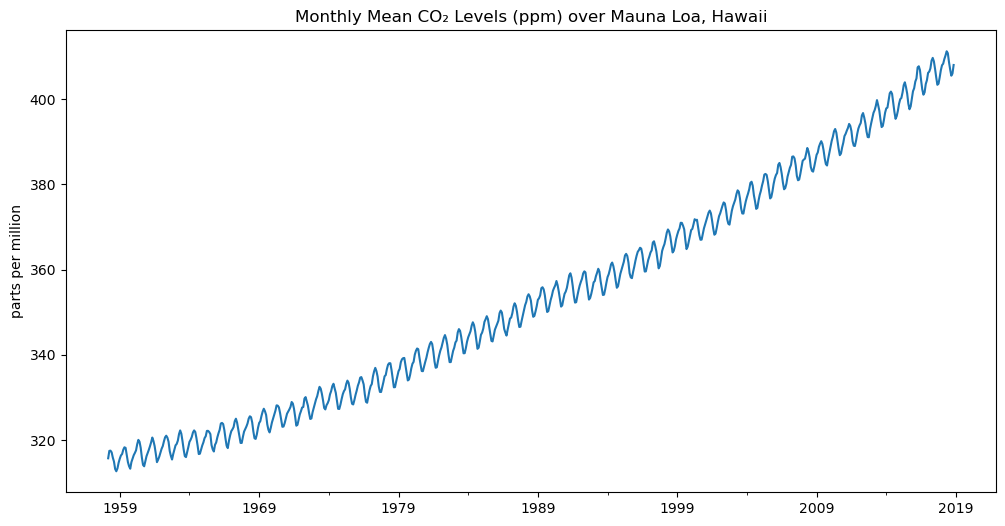

In [94]:
title = 'Monthly Mean CO₂ Levels (ppm) over Mauna Loa, Hawaii'
ylabel='parts per million'
xlabel=''
ax = df["interpolated"].plot(figsize=(12,6),title=title)
ax.autoscale(axis="x")
ax.set(xlabel=xlabel,ylabel=ylabel)

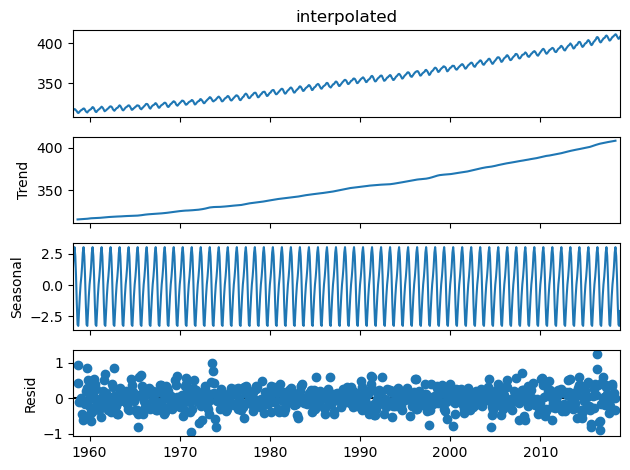

In [95]:
import matplotlib.pyplot as plt
result = seasonal_decompose(df["interpolated"])
result.plot()
plt.show()

In [97]:
from pmdarima import auto_arima   
auto_arima(df["interpolated"],seasonal=True,m=12).summary()   

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  729
Model:             SARIMAX(0, 1, 3)x(1, 0, [1], 12)   Log Likelihood                -205.685
Date:                              Tue, 27 Jan 2026   AIC                            423.371
Time:                                      21:05:55   BIC                            450.913
Sample:                                  03-01-1958   HQIC                           433.998
                                       - 11-01-2018                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3564      0.036     -9.859      0.000      -0.427      -0.286
ma.L2         -0.0221      0.036     -0.607      0.544      -0.093       0.049
ma.L3         -0.0856      0.035     -2.424      0.015      -0.155      -0.016
ar.S.L12       0.9996      0.000   3138.111      0.000       0.999       1.000
ma.S.L12      -0.8672      0.021    -41.099      0.000      -0.909      -0.826
sigma2         0.0955      0.005     20.358      0.000       0.086       0.105
===================================================================================
Ljung-Box (L1) (Q):                   0.07   Jarque-Bera (JB):                 4.08
Prob(Q):                              0.79   Prob(JB):                         0.13
Heteroskedasticity (H):               1.13   Skew:                             0.00
Prob(H) (two-sided):                  0.33   Kurtosis:                         3.37
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [100]:
train = df.iloc[:717]
test = df.iloc[717:]

model = SARIMAX(train["interpolated"],order=(0,1,3),seasonal_order=(1,0,1,12))
result = model.fit()

In [102]:
start = len(train)
end = start + len(test) - 1
#dynamic=False
#猜後天 是拿預測明天 還是拿實際的明天 
#dynamic=False 拿實際的明天 
predictions = result.predict(start=start,end=end,dynamic=False)


[Text(0.5, 0, ''), Text(0, 0.5, 'parts per million')]

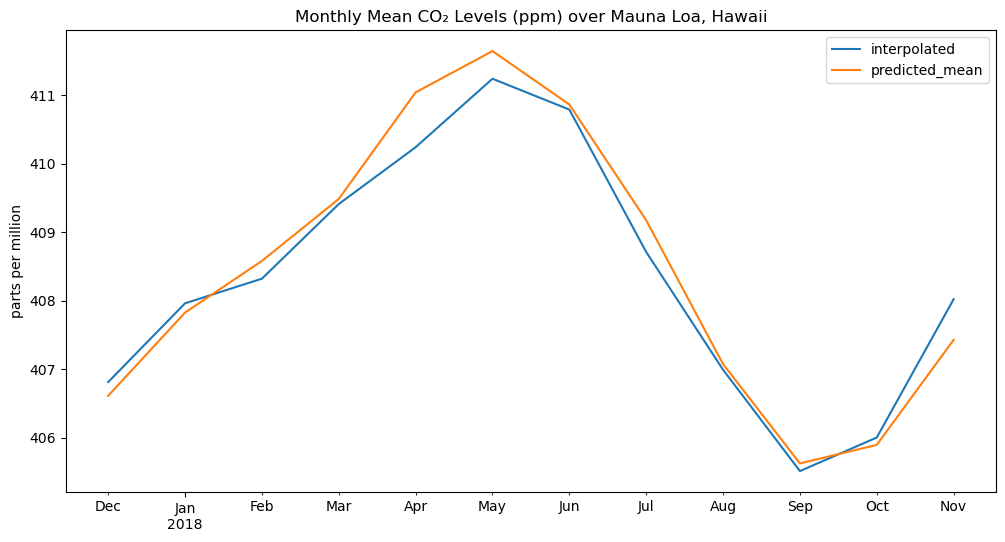

In [103]:
title = 'Monthly Mean CO₂ Levels (ppm) over Mauna Loa, Hawaii'
ylabel='parts per million'
xlabel=''
ax = test["interpolated"].plot(legend=True,figsize=(12,6),title=title)
predictions.plot(legend = True)
ax.autoscale(axis="x")
ax.set(xlabel=xlabel,ylabel = ylabel)

## 梯度下降練習
Wt+1 = Wt  - learning rate * gradient

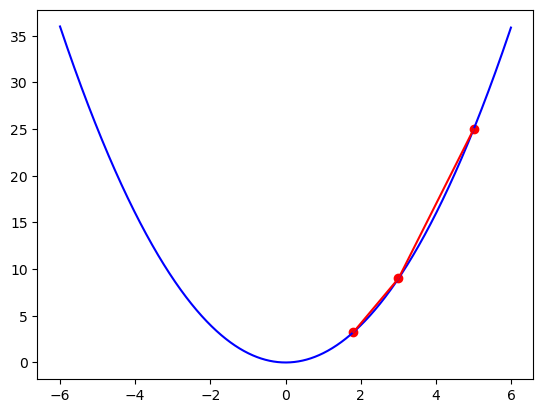

In [ ]:
import numpy as np

import matplotlib.pyplot as plt

def func(x):return x ** 2
def dfunc(x):return 2 *ｘ

def GD(x_start,df,epochs,lr):
    """  梯度下降法。給定起始點與目標函數的一階導函數，求在epochs次反覆運算中x的更新值
        :param x_start: x的起始點    
        :param df: 目標函數的一階導函數    
        :param epochs: 反覆運算週期    
        :param lr: 學習率    
        :return: x在每次反覆運算後的位置（包括起始點），長度為epochs+1    
    """   
    xs = np.zeros(epochs + 1) 
    w = x_start
    xs[0] = w
    for i in range(epochs):
        dx = df(w)
        w += -dx * lr
        xs[i+1] = w
    return xs
x_start = 5
epochs = 5
lr = 0.2
w  = GD(x_start,dfunc,epochs,lr)
color = "r"
import numpy as np
t = np.arange(-6.0,6.0,0.01)
plt.plot(t,func(t),c="b")    
plt.plot(w,func(w),c=color,label=f"lr:{lr}")
plt.scatter(w,func(w),c=color)
#plt.plot()